# Stitching Images (large dataset)

In [1]:
import h5py
import matplotlib.pyplot as plt
import numpy as np

import microscopy_data_analysis as mda

In [2]:
#for the next line to work, the file create_example_for_grid_stitching.py
#should be in the same directory as this notebook
import create_data_for_grid_stitching

create_data_for_grid_stitching.run_script()

In [3]:
example_path="example_images"
pathlist=mda.get_files_of_format(example_path,"tif")
N=len(pathlist)
pathlist[:3]

['example_images/image_00.tif',
 'example_images/image_01.tif',
 'example_images/image_02.tif']

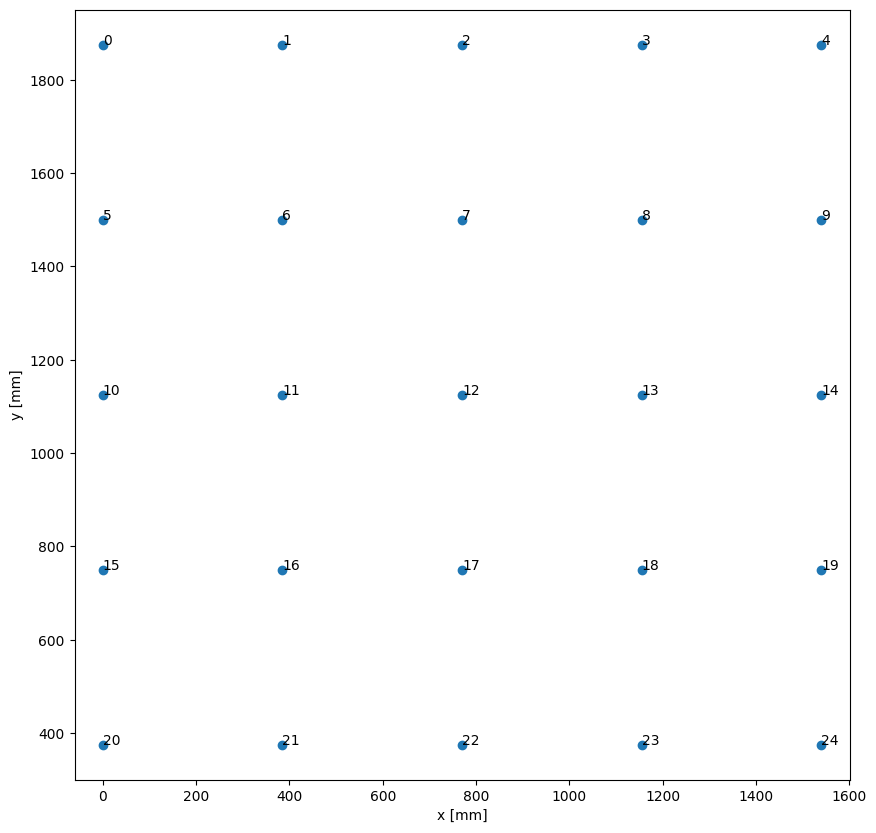

In [4]:
%matplotlib inline
positions=np.zeros([N,2])
counter=0
for i in range(5):
    for j in range(5):
        if counter==len(positions):
            break
        positions[counter]=j*385,5*375-i*375
        counter+=1

plt.figure(figsize=[10,10])
plt.plot(positions[:,0],positions[:,1],'o')
for i in range(len(positions)):
    plt.text(positions[i,0],positions[i,1],str(i))
plt.xlabel(r"x [mm]")
plt.ylabel(r"y [mm]")
plt.axis("equal")
plt.show()

Even though set of images is small, this example shows a workflow, 
as if the size of the image stack would be large (potentially bigger than RAM).

Side note: In this example we use a grid of images again, but any other arangement of overlapping images would work as well.

In [5]:
stack=mda.image_stack(mode='storage')

For .h5 provide the path to the h5-file (that serves as h5-directory) via the 'set_directory_path' method
For .tif, .png, ... image files  either provide  a list of relative or absolute filepaths via 'set_img_list'
or provide the folder containing only the contributing images via 'set_directory_path'


In [6]:
# identical to minimal example
stack.set_img_list(pathlist)
stack.sniff_dimensions()
stack.set_units_per_pixel(1.1)
stack.set_positions(positions)
polygons,anchor_points=stack.make_polygons()

In [7]:
stack.create_h5cube_duplicate_for_modifying("example_data.h5",dset_name="data")

100%|██████████| 25/25 [00:00<00:00, 153.40it/s]


histo: 100%|██████████| 25/25 [00:00<00:00, 162.40it/s]


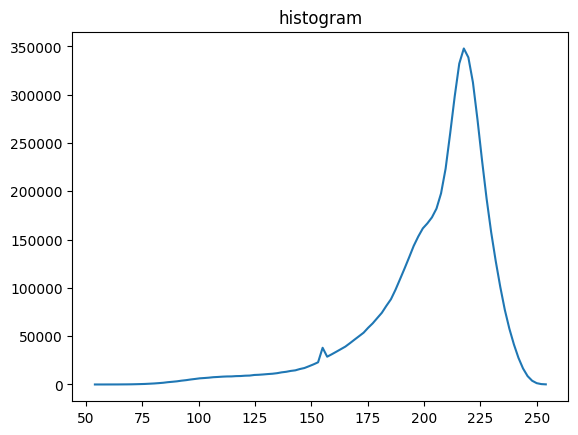

In [8]:
# let's have a look into the histogram of brightness values
# of all images in the stack

vmin,vmax,vbins,vhist=stack.stats(dset_name="data")
plt.title("histogram")
plt.plot(mda.bin_centering(vbins), vhist)
plt.show()

histo: 100%|██████████| 25/25 [00:00<00:00, 589.59it/s]


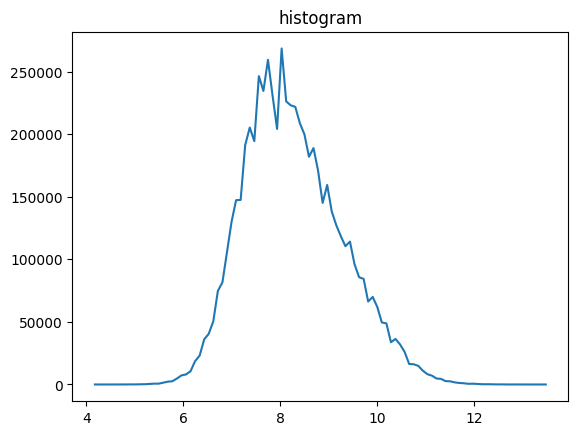

In [9]:
# z-transform (subtraction of mean and division by standard deviation) is 
# usually a good idea, since the contrast of images is often rescaled 
# to the file format, when saved
stack.z_transform_images() 
# no dset_name given, will overwrite existing dataset 
# (only in the modifiable h5 file)

vmin,vmax,vbins,vhist=stack.stats(dset_name="data")
plt.title("histogram")
plt.plot(mda.bin_centering(vbins), vhist)
plt.show()

histo: 100%|██████████| 25/25 [00:00<00:00, 1042.50it/s]


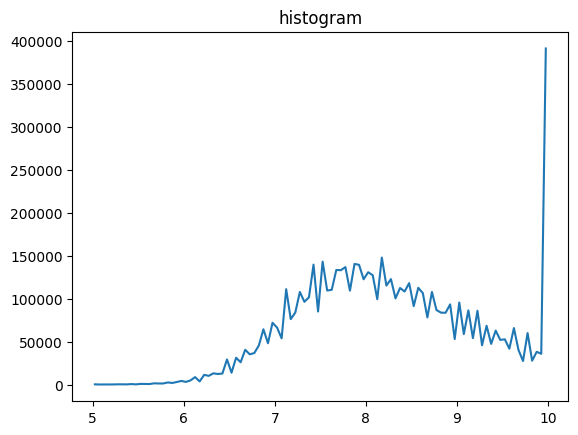

In [10]:
stack.clip(5,10,new_dset_name="clipped")
# now for example this clipping might not be very useful,
# so we do not overwrite 'data' but create 'clipped' instead

vmin,vmax,vbins,vhist=stack.stats(dset_name="clipped")
plt.title("histogram")
plt.plot(mda.bin_centering(vbins), vhist)
plt.show()

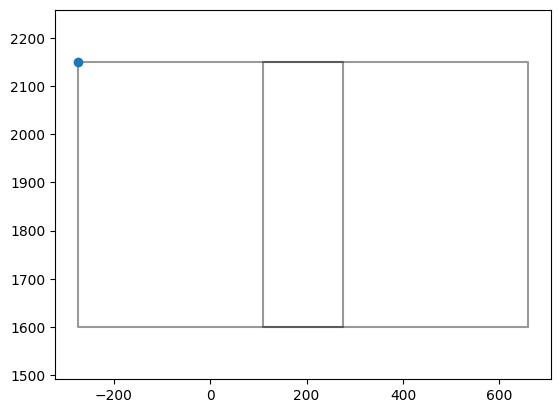

In [11]:
%matplotlib inline

# check for two images, if there is overlap
# also origin (anchor) of the pixel coordinates, shown as blue dot, should be 
# in the left upper corner of an image

index=0
plt.plot(np.array(polygons[index].exterior.xy[0]),np.array(polygons[index].exterior.xy[1]),'k-',alpha=0.4)
plt.plot(anchor_points[index][0],anchor_points[index][1],'o')
index=1
plt.plot(np.array(polygons[index].exterior.xy[0]),np.array(polygons[index].exterior.xy[1]),'k-',alpha=0.4)
plt.axis("equal")
plt.show()

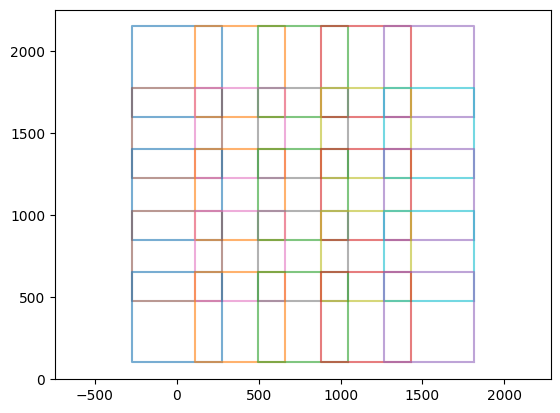

In [12]:
# show all images (abstracted as polygons)
for index in range(len(stack.polygons)):
    plt.plot(np.array(stack.polygons[index].exterior.xy[0]),np.array(stack.polygons[index].exterior.xy[1]),'-',alpha=0.6)
plt.axis("equal")
plt.show()

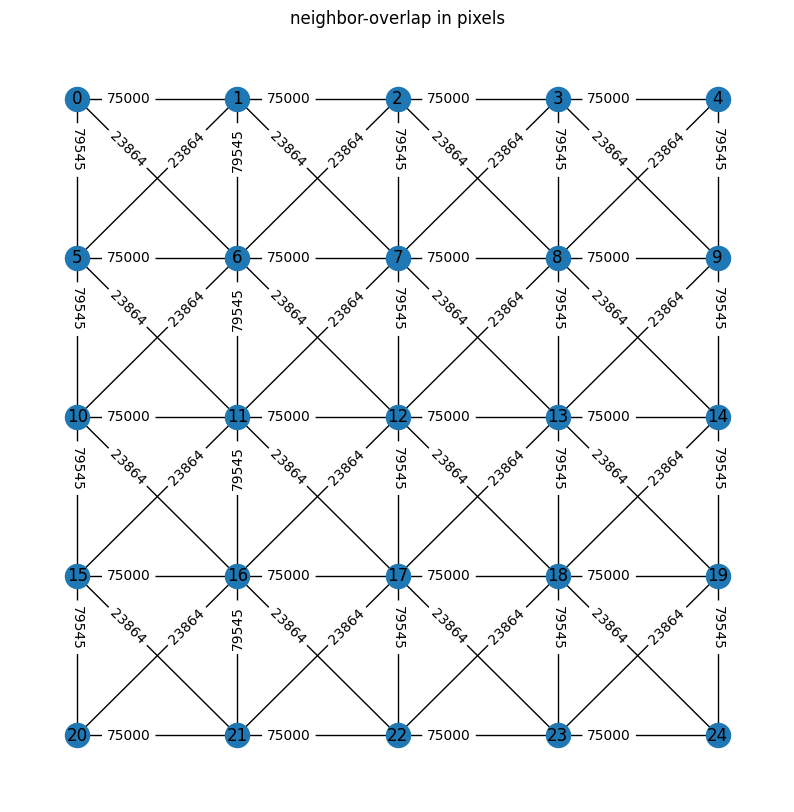

In [26]:
connected_groups=stack.connection_groups()
stack.plot_connection_network(figsize=[10,10],relative=False)

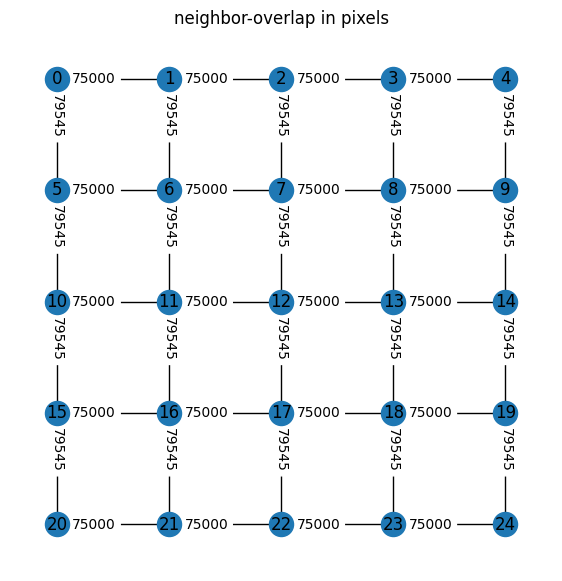

In [27]:
# to accelerate calculation one can neglect diagonal connections
connected_groups=stack.connection_groups(minimal_number_of_pixels=50_000)
stack.plot_connection_network(figsize=[7,7],relative=False)

In [15]:
pair_shifts=stack.check_pairs(dset_name='data')

100%|██████████| 40/40 [00:02<00:00, 13.72it/s]


In [16]:
moved_polygons=stack.optimize_positions()

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         1.8024e+05                                    3.93e+02    
       1              3         1.0144e+05      7.88e+04       2.99e+02       2.21e+02    
       2              4         1.0012e+05      1.32e+03       2.99e+02       3.12e+02    
       3              5         6.7081e+04      3.30e+04       7.49e+01       1.41e+02    
       4              6         6.6346e+04      7.35e+02       1.50e+02       1.81e+02    
       5              7         5.6730e+04      9.62e+03       3.74e+01       9.15e+01    
       6              8         5.3785e+04      2.95e+03       7.49e+01       8.26e+01    
       7             10         5.1712e+04      2.07e+03       1.87e+01       2.80e+01    
       8             11         5.0855e+04      8.57e+02       1.87e+01       1.34e+01    
       9             12         5.0224e+04      6.32e+02       1.87e+01       1.41e+01    

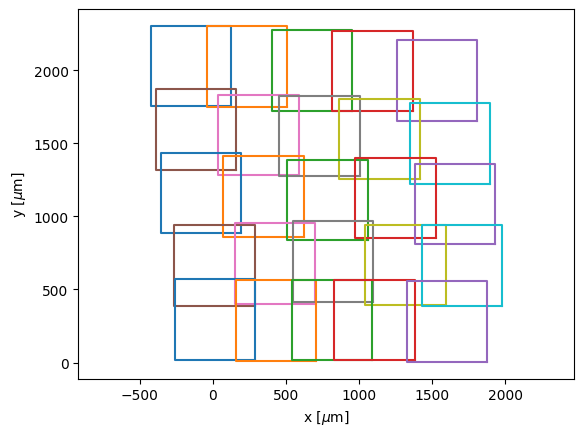

In [17]:
%matplotlib inline
for i in range(len(moved_polygons)):
    plt.plot(np.array(moved_polygons[i].exterior.xy[0]),np.array(moved_polygons[i].exterior.xy[1]))#'k-')
plt.xlabel(r"x [$\mu$m]")
plt.ylabel(r"y [$\mu$m]")
plt.axis("equal")
plt.show()

In [18]:
stack.map_from_polygons_h5(moved_polygons,boolean_mask=True,blending="average",dset_name="data")

Rows: 100%|██████████| 5/5 [00:00<00:00, 32.92it/s]


For very large maps, the map typically can not be displayed fully by plt.imshow. 
Small parts are no problem, like:

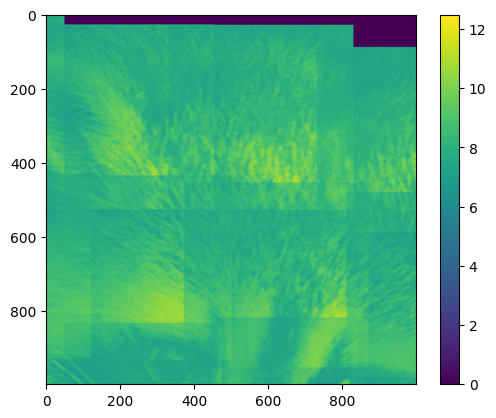

In [19]:
# inspect the image map
with h5py.File("example_data.h5",'r') as f:
    img=f["map"] 
    #this does not load the image into RAM yet, only when sliced
    # --> img=f["map"][:]  would load all data into RAM (and should be avoided)
    imgsection=img[0:1000,800:1800] # loads a 1000x1000 slice into RAM
plt.imshow(imgsection)
plt.colorbar()
plt.show()

Rows: 100%|██████████| 5/5 [00:00<00:00, 56.71it/s]


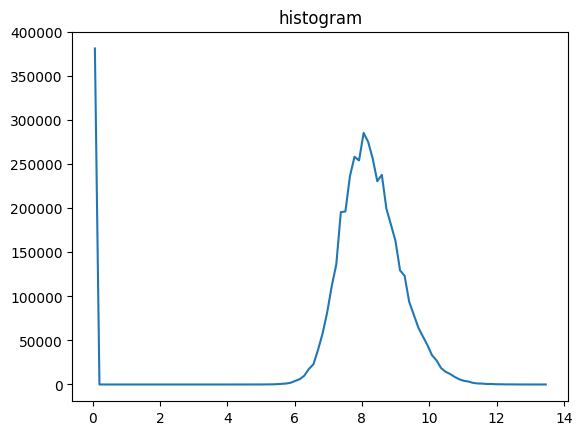

In [20]:
# inspect the brightness value histogram
vmin,vmax,vbins,vhist=stack.stats(dset_name="map")
plt.title("histogram")
plt.plot(mda.bin_centering(vbins), vhist)
plt.show()

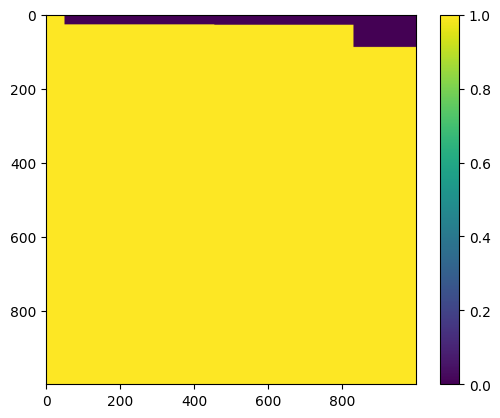

In [21]:
# Most of the zeros in the first histogram are from the borders of the image map.
# To ignore these values, we can use the boolean_mask, 
# which yields False in such regions.
with h5py.File("example_data.h5",'r') as f:
    img=f["boolean_mask"] 
    #this does not load the image into RAM yet, only when sliced
    # --> img=f["map"][:]  would load all data into RAM (and should be avoided)
    imgsection=img[0:1000,800:1800] # loads a 1000x1000 slice into RAM
plt.imshow(imgsection)
plt.colorbar()
plt.show()

Rows: 100%|██████████| 5/5 [00:00<00:00, 47.20it/s]


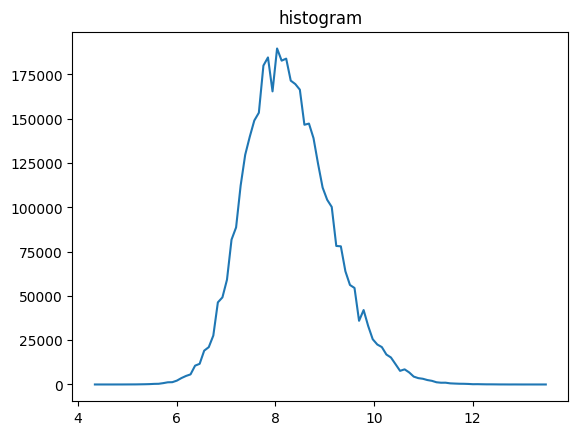

In [22]:
# brightness histogram with boolean mask
vmin,vmax,vbins,vhist=stack.stats(dset_name="map",mask="boolean_mask")
plt.title("histogram")
plt.plot(mda.bin_centering(vbins), vhist)
plt.show()

Rows: 100%|██████████| 5/5 [00:00<00:00, 83.64it/s]


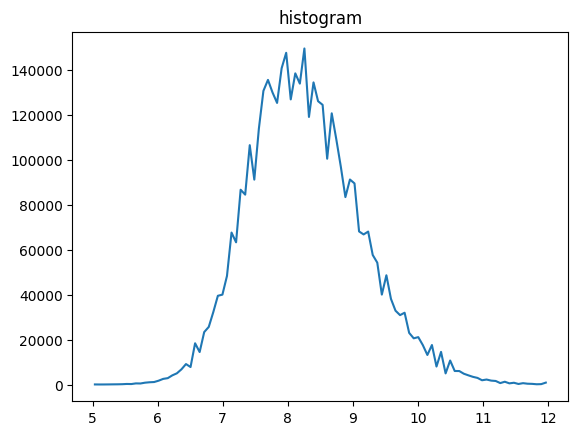

In [23]:
# clip the range of brightness values for better contrast
stack.clip(5,12,dset_name="map",new_dset_name="clipped")

vmin,vmax,vbins,vhist=stack.stats(dset_name="clipped",mask="boolean_mask")
plt.title("histogram")
plt.plot(mda.bin_centering(vbins), vhist)
plt.show()

Rows: 100%|██████████| 5/5 [00:00<00:00, 33.30it/s]


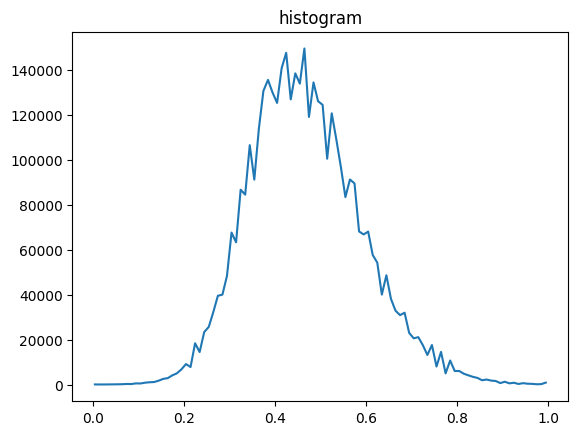

In [24]:
# rescale the values between 0 and 1 for saving the image in float32
# (alternatively rescaling to 0 and 255 for uint8, would be an option as well)
# stack.normalize(dset_name="clipped",new_max=255)

stack.normalize(dset_name="clipped")

vmin,vmax,vbins,vhist=stack.stats(dset_name="clipped",mask="boolean_mask")
plt.title("histogram")
plt.plot(mda.bin_centering(vbins), vhist)
plt.show()

In [25]:
# for viewing the images with standard software, big_tiff=False can be used
# for very big maps big_tiff=True must be used and images can be opened
# for example with imagej/Fiji  (for fast zooming use: mda.h5_to_pyramidal_tiff)
mda.h5_to_tiff(h5_path="example_data.h5",dset_name="clipped",out_path="stitching_example_large.tif",big_tiff=False,dtype='f4')

Saved BigTIFF: stitching_example_large.tif
